In [90]:
#BASELINE MODEL - logistic regression model for predicting management strategy, 81% baseline accuracy.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix)


In [112]:
#LOAD THE DATASET
data = pd.read_excel("/Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/synthetic_vestibular_schwannoma_data.xlsx")
data.head()

,age_at_diagnosis,Sex,BMI,tumour_laterality,Scan 1: Volume,linear_regression_growth_rate_cm3,charlson_comorbidity_index,koos_grade_at_presentation,Management
0,53,M,26.686467,R,97.735,-0.073669,0,1,SRS
1,66,F,28.385639,L,466.545,-0.204869,2,1,Surveillance
2,30,F,25.541945,R,182.759,-0.274673,0,1,Surveillance
3,57,F,NaN,R,0.000,NaN,0,1,SRS
4,59,M,26.573149,R,0.000,0.563720,2,4,SRS


In [113]:
#Train test split
X = data[['BMI', 'tumour_laterality', 'age_at_diagnosis', 'Sex', 'Scan 1: Volume', 'linear_regression_growth_rate_cm3', 'charlson_comorbidity_index']]
y = data["Management"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
#BASELINE PREPROC PIPELINE
numeric_cols = ["BMI", "Scan 1: Volume", "linear_regression_growth_rate_cm3", "charlson_comorbidity_index", "age_at_diagnosis"]
categorical_cols = ["Sex", "tumour_laterality"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        drop="if_binary",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

# pipeline = Pipeline([
  #  ("preprocessor", preprocessor),
   # ("model") #ADD MODELL PARAMETERS HERE
#])

preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [115]:
#SVM
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
    kernel="rbf",
    C=50,
    gamma=0.01,
    probability=True,
    random_state=42
    ))
])

svm_cv_results = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("SVM Trial Run")
print("Mean CV accuracy:", svm_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", svm_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", svm_cv_results["test_f1_macro"].mean())


SVM Trial Run
Mean CV accuracy: 0.7529999999999999
Mean CV balanced accuracy: 0.7498512803350236
Mean CV macro F1: 0.7577177999671845


In [116]:
#Random Forrest (note - hyperparameters have been gridsearched)
RF_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=380,
        max_depth=10,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ))
])

RF_cv_results = cross_validate(
    RF_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("RF Trial Run")
print("Mean CV accuracy:", RF_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", RF_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", RF_cv_results["test_f1_macro"].mean())


RF Trial Run
Mean CV accuracy: 0.764
Mean CV balanced accuracy: 0.7643224321469316
Mean CV macro F1: 0.7695472549869108


In [117]:
#K Nearest Neighbour

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=10
    ))
])

knn_cv_results = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("KNN Trial Run")
print("Mean CV accuracy:", knn_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", knn_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", knn_cv_results["test_f1_macro"].mean())


KNN Trial Run
Mean CV accuracy: 0.7335
Mean CV balanced accuracy: 0.7329953840207555
Mean CV macro F1: 0.7387756936685601


In [118]:
#XGBoost

# Encode target labels as integers as wont work otherwise for xgb
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

XGB_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

XGB_cv_results = cross_validate(
    XGB_pipeline,
    X_train,
    y_train_encoded,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("XGBoost Trial Run")
print("Mean CV accuracy:", XGB_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", XGB_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", XGB_cv_results["test_f1_macro"].mean())


XGBoost Trial Run
Mean CV accuracy: 0.7467500000000001
Mean CV balanced accuracy: 0.7486256221326236
Mean CV macro F1: 0.7523158640489729


In [119]:
#LogReg (hyperparameter tuned C)

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        C=0.1
    ))
])

log_cv_results = cross_validate(
    log_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    }
)

print("LogReg Trial Run")
print("Mean CV accuracy:", log_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", log_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", log_cv_results["test_f1_macro"].mean())


LogReg Trial Run
Mean CV accuracy: 0.7502500000000001
Mean CV balanced accuracy: 0.749529205495013
Mean CV macro F1: 0.7561086871421044


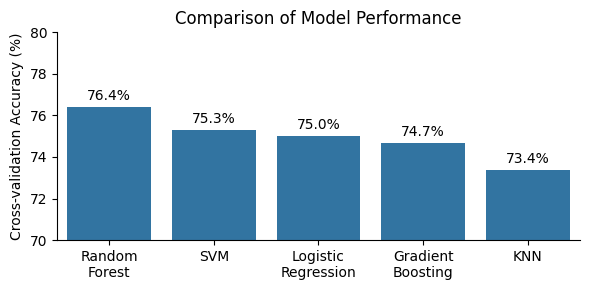

In [121]:
# Mean CV accuracies (convert to percentages)
results = pd.DataFrame({
    "Model": [
        "Logistic\nRegression",
        "SVM",
        "Random\nForest",
        "KNN",
        "Gradient\nBoosting"
    ],
    "Accuracy": [
        log_cv_results["test_accuracy"].mean() * 100,
        svm_cv_results["test_accuracy"].mean() * 100,
        RF_cv_results["test_accuracy"].mean() * 100,
        knn_cv_results["test_accuracy"].mean() * 100,
        XGB_cv_results["test_accuracy"].mean() * 100
    ]
})

# Sort from best to worst
results = results.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(6, 3))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

# Add accuracy labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.ylim(70, 80)
plt.ylabel("Cross-validation Accuracy (%)")
plt.xlabel("")
plt.title("Comparison of Model Performance")
sns.despine()
plt.tight_layout()
plt.show()

In [122]:
#Creating a stacked ensemble model pipeline that vote

ensemble_model = VotingClassifier(
    estimators=[("logistic_regression", log_pipeline), ("svm", svm_pipeline), ("random_forest", RF_pipeline), ("knn", knn_pipeline), ("xgboost", XGB_pipeline)],
    voting="soft",       #soft rather than hard voting = based on confidence rather than single vote
    weights=None,
    n_jobs=-1
)
ensemble_model

,estimators,"[('logistic_regression', ...), ('svm', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [123]:
#CV results of ensemble model
ensemble_cv_results = cross_validate(ensemble_model, X_train, y_train, cv=5,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    },
    n_jobs=-1
)
print("Soft-Voting Ensemble Cross-Validation Results")
print("Mean CV accuracy:", ensemble_cv_results["test_accuracy"].mean())
print("Mean CV balanced accuracy:", ensemble_cv_results["test_balanced_accuracy"].mean())
print("Mean CV macro F1:", ensemble_cv_results["test_f1_macro"].mean())

#TRAIN
ensemble_model.fit(X_train, y_train)

#TEST
y_pred_ensemble = ensemble_model.predict(X_test)
y_pred_proba_ensemble = ensemble_model.predict_proba(X_test)
ensemble_test_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_ensemble)
ensemble_test_f1_macro = f1_score(y_test, y_pred_ensemble, average="macro")

print("\nSoft-Voting Ensemble Test Results")
print("Test accuracy:", ensemble_test_accuracy)
print("Test balanced accuracy:", ensemble_test_balanced_accuracy)
print("Test macro F1:", ensemble_test_f1_macro)

print("\nClassification Report")
print(classification_report(
        y_test,
        y_pred_ensemble
    )
)

Soft-Voting Ensemble Cross-Validation Results
Mean CV accuracy: 0.7622500000000001
Mean CV balanced accuracy: 0.7620197192007965
Mean CV macro F1: 0.7680203481099699

Soft-Voting Ensemble Test Results
Test accuracy: 0.767
Test balanced accuracy: 0.7669416815526873
Test macro F1: 0.7730383969151621

Classification Report
              precision    recall  f1-score   support

         SRS       0.68      0.80      0.73       357
     Surgery       0.89      0.76      0.82       279
Surveillance       0.79      0.74      0.76       364

    accuracy                           0.77      1000
   macro avg       0.79      0.77      0.77      1000
weighted avg       0.78      0.77      0.77      1000

